# 1. 해빙 면적 이상치 탐지 모델

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
area = pd.read_csv('/content/drive/MyDrive/arctic_data/area_long.csv')
europe =  pd.read_csv('/content/drive/MyDrive/arctic_data/europe_climate.csv')
sst =  pd.read_csv('/content/drive/MyDrive/arctic_data/Arctic_SST_Analysis_Data.csv')
ao =  pd.read_csv('/content/drive/MyDrive/arctic_data/ao_filtered.csv')

In [ ]:
# ==================== Cell 2: 월별 집계 및 병합 (기존 로직 + 커버리지 체크 추가) ====================
europe['date'] = pd.to_datetime(europe['date'])
europe['year_month'] = europe['date'].dt.to_period('M')

# Monthly aggregation for europe
europe_monthly_agg = europe.groupby('year_month').agg(
    mean_t850_celsius=('mean_t850_celsius', 'mean'),
    mean_t2m_celsius=('mean_t2m_celsius', 'mean'),
    mean_z500=('mean_z500', 'mean'),
    mean_prate=('mean_prate', 'mean'),
    mean_slp_hpa=('mean_slp_hpa', 'mean'),
    mean_wind_speed_250=('mean_wind_speed_250', 'mean')
).reset_index()

ao['Date'] = pd.to_datetime(ao['Date'])
ao['year_month'] = ao['Date'].dt.to_period('M')
ao_monthly = ao.groupby('year_month')['AO_Index'].mean().reset_index()

sst['time'] = pd.to_datetime(sst['time'])
sst['year_month'] = sst['time'].dt.to_period('M')
sst_monthly = sst.groupby('year_month')['TSKINWTR'].mean().reset_index()

area['date'] = pd.to_datetime(area['year'].astype(str) + '-' + area['month_num'].astype(str) + '-01')
area['year_month'] = area['date'].dt.to_period('M')
area_monthly = area.groupby('year_month')['area_value'].mean().reset_index()

# inner join 전에 각 데이터셋 기간을 먼저 확인 -> 병합 후 얼마나 손실되는지 파악
print("각 데이터셋 기간:")
for name, d in [('europe', europe_monthly_agg), ('sst', sst_monthly),
                 ('ao', ao_monthly), ('area', area_monthly)]:
    print(f"  {name}: {d['year_month'].min()} ~ {d['year_month'].max()}  ({len(d)}개월)")

df_combined = europe_monthly_agg.merge(sst_monthly, on='year_month', how='inner')
df_combined = df_combined.merge(ao_monthly, on='year_month', how='inner')
df_combined = df_combined.merge(area_monthly, on='year_month', how='inner')
df_combined = df_combined.set_index(pd.to_datetime(df_combined['year_month'].astype(str) + '-01'))
df_combined = df_combined.drop(columns=['year_month'])

print(f"\n병합 후 최종 기간: {df_combined.index.min()} ~ {df_combined.index.max()}  ({len(df_combined)}개월)")
display(df_combined.head())

각 데이터셋 기간:
  europe: 2000-01 ~ 2026-06  (318개월)
  sst: 2000-01 ~ 2026-05  (317개월)
  ao: 2000-01 ~ 2026-05  (317개월)
  area: 2000-01 ~ 2026-12  (324개월)

병합 후 최종 기간: 2000-01-01 00:00:00 ~ 2026-05-01 00:00:00  (317개월)


,mean_t850_celsius,mean_t2m_celsius,mean_z500,mean_prate,mean_slp_hpa,mean_wind_speed_250,TSKINWTR,AO_Index,area_value
year_month,,,,,,,,,
2000-01-01,-4.181620,1.023189,5424.016813,0.000023,1014.291652,26.049841,272.26678,0.665,14.25950
2000-02-01,-3.147531,2.413326,5417.767407,0.000025,1011.907288,24.780429,272.16122,1.060,15.14771
2000-03-01,-2.451394,3.575524,5450.330084,0.000022,1014.241815,24.250502,272.13068,-0.256,15.25001
2000-04-01,0.867558,7.105605,5496.645230,0.000025,1011.548113,21.808205,272.15040,-0.576,14.57881
2000-05-01,4.629686,10.712463,5593.623074,0.000020,1014.013966,20.220714,272.43660,1.152,13.21552


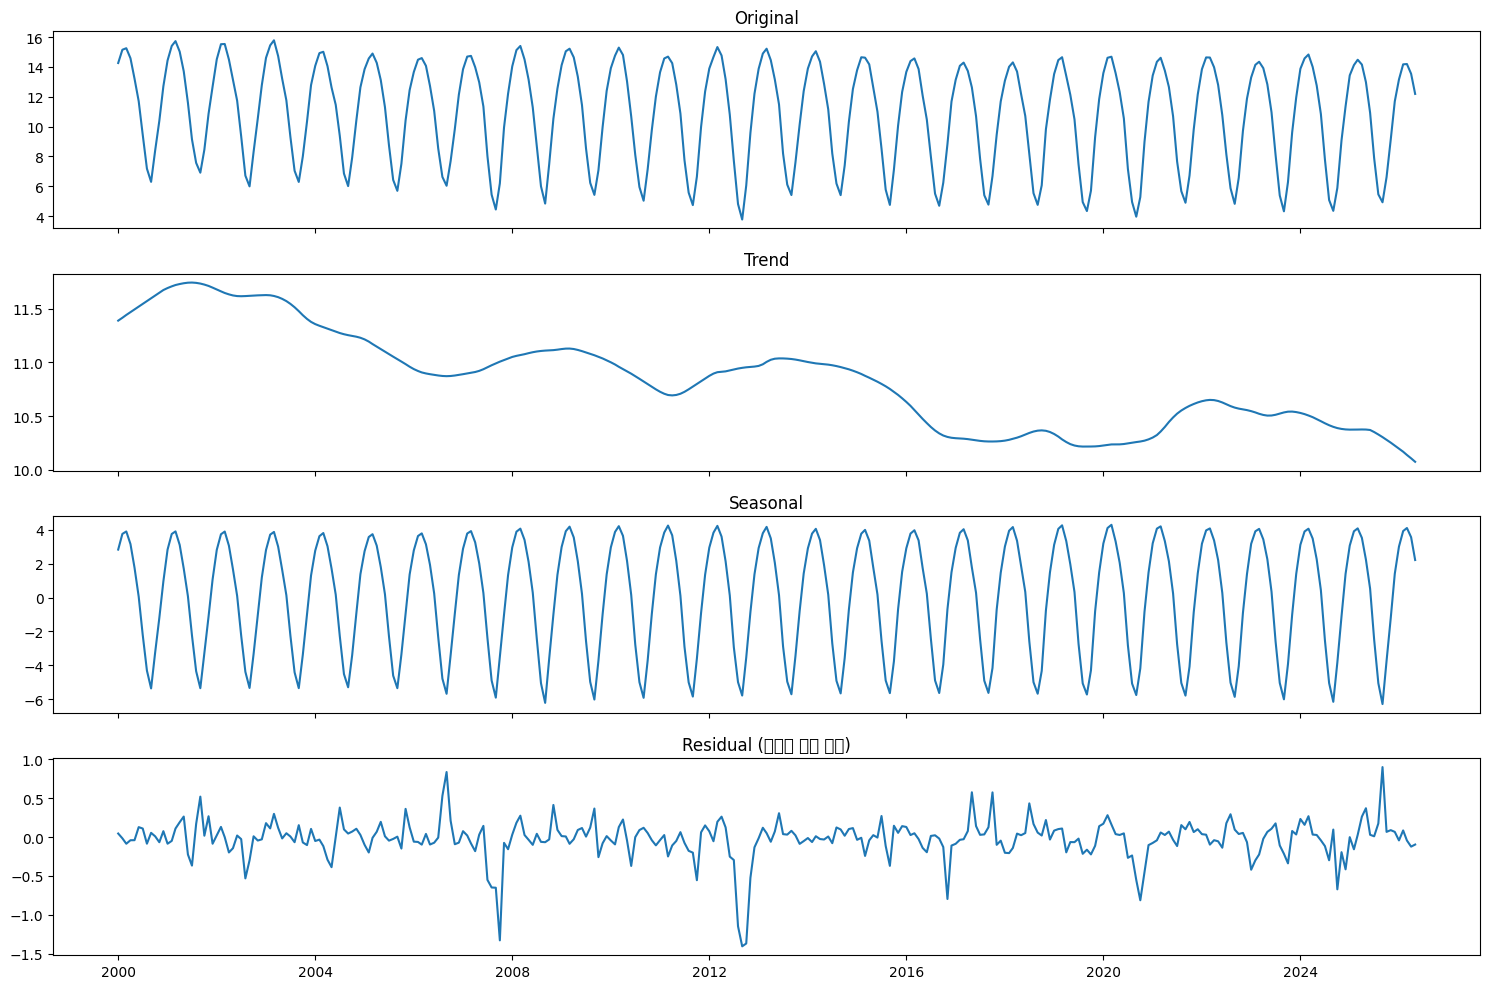

In [ ]:
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt

# ==================== Cell 3: [수정] 계절성 제거 - STL 분해 ====================
stl = STL(df_combined['area_value'], period=12, robust=True)
stl_result = stl.fit()

df_combined['trend'] = stl_result.trend
df_combined['seasonal'] = stl_result.seasonal
df_combined['residual'] = stl_result.resid

fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)
axes[0].plot(df_combined.index, df_combined['area_value']); axes[0].set_title('Original')
axes[1].plot(df_combined.index, df_combined['trend']); axes[1].set_title('Trend')
axes[2].plot(df_combined.index, df_combined['seasonal']); axes[2].set_title('Seasonal')
axes[3].plot(df_combined.index, df_combined['residual']); axes[3].set_title('Residual (이상치 탐지 대상)')
plt.tight_layout()
plt.show()

In [ ]:
# ==================== Cell 4: [수정] 이상치 탐지 - 잔차 기반 Z-score ====================
# num_std: 1.5 -> 2.0 (1.5는 정규분포 기준 약 13%가 이상치로 잡혀 과도하게 관대함)
window_size = 12
num_std = 2.0

df_combined['resid_rolling_mean'] = df_combined['residual'].rolling(window=window_size, min_periods=1).mean()
df_combined['resid_rolling_std'] = df_combined['residual'].rolling(window=window_size, min_periods=1).std()
df_combined['z_score'] = (df_combined['residual'] - df_combined['resid_rolling_mean']) / df_combined['resid_rolling_std']

df_combined['anomaly_stat'] = df_combined['z_score'].abs() > num_std
anomalies_stat = df_combined[df_combined['anomaly_stat']]

print(f"통계 기반(STL + Z-score) 이상치 개수: {len(anomalies_stat)} / {len(df_combined)}")
display(anomalies_stat[['area_value', 'residual', 'z_score']])

통계 기반(STL + Z-score) 이상치 개수: 24 / 317


,area_value,residual,z_score
year_month,,,
2001-07-01,9.14852,-0.367037,-2.033709
2001-09-01,6.91230,0.518727,2.036496
2002-08-01,6.71440,-0.530825,-2.087363
2004-04-01,14.04882,-0.290814,-2.232873
2004-05-01,12.62320,-0.387171,-2.105422
2004-07-01,9.38876,0.378258,2.118028
2005-11-01,10.41270,0.361513,2.337306
2006-08-01,6.62687,0.528359,2.378153
2006-09-01,6.03629,0.834694,2.365542


```anomaly_stat```:  STL로 계절성을 제거한 잔차 residual에 대해 Z-score를 계산해, |z_score| > 2.0이면 True

통계적으로 정상범위를 벗어난 달을 표시하는 이진값(True/False)

In [ ]:
from sklearn.ensemble import IsolationForest

# ==================== Cell 5: [추가] Isolation Forest 기반 이상치 탐지 (교차검증용) ====================
# STL+Zscore(통계 기반)와 서로 다른 방법론으로 교차 검증하기 위한 두 번째 모델
iso_features = pd.DataFrame({
    'residual': df_combined['residual'],
    'diff_1': df_combined['area_value'].diff(),
    'rolling_std_3': df_combined['area_value'].rolling(3, min_periods=1).std(),
}).fillna(0)

iso_model = IsolationForest(contamination=0.05, random_state=42)
df_combined['anomaly_iso'] = iso_model.fit_predict(iso_features) == -1
df_combined['anomaly_score_iso'] = -iso_model.score_samples(iso_features)  # 값이 클수록 이상 정도 큼

agreement = (df_combined['anomaly_stat'] == df_combined['anomaly_iso']).mean()
print(f"STL+Zscore vs Isolation Forest 일치율: {agreement:.1%}")

STL+Zscore vs Isolation Forest 일치율: 92.4%


```anomaly_iso```:  Isolation Forest 모델이 residual, diff_1(전월 대비 변화량), rolling_std_3(3개월 표준편차) 3가지를 함께 보고 "정상 패턴에서 고립된 정도"를 판단

contamination=0.05로 설정했으니 전체 데이터 중 대략 상위 5%를 이상치로 판정 → True

다변량 관점에서 "여러 특성을 종합했을 때 패턴이 이질적인 달"을 표시하는 이진값

```anomaly_score_iso```:Isolation Forest의 anomaly_iso(True/False)는 이진 판정이지만, 그 판정 뒤에는 연속적인 이상 정도 점수가 있음. 그 점수

코드에서 -iso_model.score_samples(...)로 부호를 뒤집어놨기 때문에, 값이 클수록 더 이상한(고립된) 데이터라는 뜻

"이 달이 얼마나 이상한가"를 0/1이 아니라 정도(magnitude) 로 표현한 값

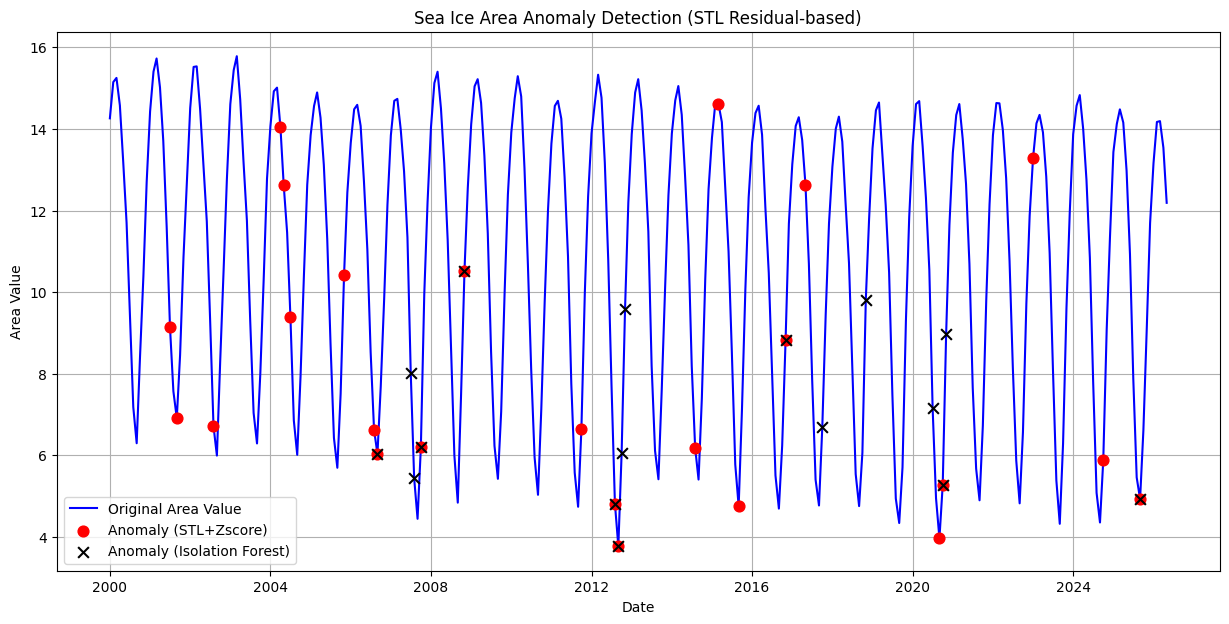

In [ ]:
# ==================== Cell 6: [수정] 이상치 시각화 (STL 잔차 기준, 두 방법 함께 표시) ====================
plt.figure(figsize=(15, 7))
plt.plot(df_combined.index, df_combined['area_value'], label='Original Area Value', color='blue')
plt.scatter(df_combined[df_combined['anomaly_stat']].index,
            df_combined[df_combined['anomaly_stat']]['area_value'],
            color='red', label='Anomaly (STL+Zscore)', marker='o', s=60, zorder=5)
plt.scatter(df_combined[df_combined['anomaly_iso']].index,
            df_combined[df_combined['anomaly_iso']]['area_value'],
            color='black', label='Anomaly (Isolation Forest)', marker='x', s=60, zorder=5)
plt.title('Sea Ice Area Anomaly Detection (STL Residual-based)')
plt.xlabel('Date'); plt.ylabel('Area Value'); plt.legend(); plt.grid(True)
plt.show()

In [ ]:
# ==================== Cell 5-1: [추가] 두 이상치 탐지 방법 교차검증 표 ====================
from sklearn.metrics import cohen_kappa_score

# 1) 개월 수 기준 2x2 교차표
cross_tab = pd.crosstab(df_combined['anomaly_stat'], df_combined['anomaly_iso'],
                         rownames=['STL+Zscore'], colnames=['Isolation Forest'])
print("교차검증 표 (개월 수):")
display(cross_tab)

# 2) 비율(%) 기준 교차표
cross_tab_pct = pd.crosstab(df_combined['anomaly_stat'], df_combined['anomaly_iso'],
                             rownames=['STL+Zscore'], colnames=['Isolation Forest'],
                             normalize='all') * 100
print("\n교차검증 표 (비율 %):")
display(cross_tab_pct.round(1))

# 3) 우연 수준을 보정한 일치도 (Cohen's Kappa)
kappa = cohen_kappa_score(df_combined['anomaly_stat'], df_combined['anomaly_iso'])
print(f"\n단순 일치율: {(df_combined['anomaly_stat'] == df_combined['anomaly_iso']).mean():.1%}")
print(f"Cohen's Kappa: {kappa:.3f}")

# 4) 두 방법 모두 이상치로 판정한 시점 (신뢰도 높은 최종 이상치 후보)
both_anomaly = df_combined[df_combined['anomaly_stat'] & df_combined['anomaly_iso']]
only_stat = df_combined[df_combined['anomaly_stat'] & ~df_combined['anomaly_iso']]
only_iso = df_combined[~df_combined['anomaly_stat'] & df_combined['anomaly_iso']]

print(f"\n두 방법 모두 이상치로 판정: {len(both_anomaly)}개")
print(f"STL+Zscore만 판정: {len(only_stat)}개")
print(f"Isolation Forest만 판정: {len(only_iso)}개")
display(both_anomaly[['area_value', 'residual', 'z_score', 'anomaly_score_iso']])

교차검증 표 (개월 수):


Isolation Forest,False,True
STL+Zscore,,
False,285,8
True,16,8



교차검증 표 (비율 %):


Isolation Forest,False,True
STL+Zscore,,
False,89.9,2.5
True,5.0,2.5



단순 일치율: 92.4%
Cohen's Kappa: 0.361

두 방법 모두 이상치로 판정: 8개
STL+Zscore만 판정: 16개
Isolation Forest만 판정: 8개


,area_value,residual,z_score,anomaly_score_iso
year_month,,,,
2006-09-01,6.03629,0.834694,2.365542,0.605187
2007-10-01,6.19369,-1.326897,-2.423386,0.655290
2008-11-01,10.52605,0.411703,2.217181,0.599657
2012-08-01,4.81491,-1.145614,-2.534825,0.687669
2012-09-01,3.77298,-1.403445,-2.155145,0.667601
2016-11-01,8.82599,-0.795707,-2.896820,0.581643
2020-10-01,5.27999,-0.812271,-2.217489,0.585833
2025-09-01,4.92862,0.898253,2.201313,0.607686


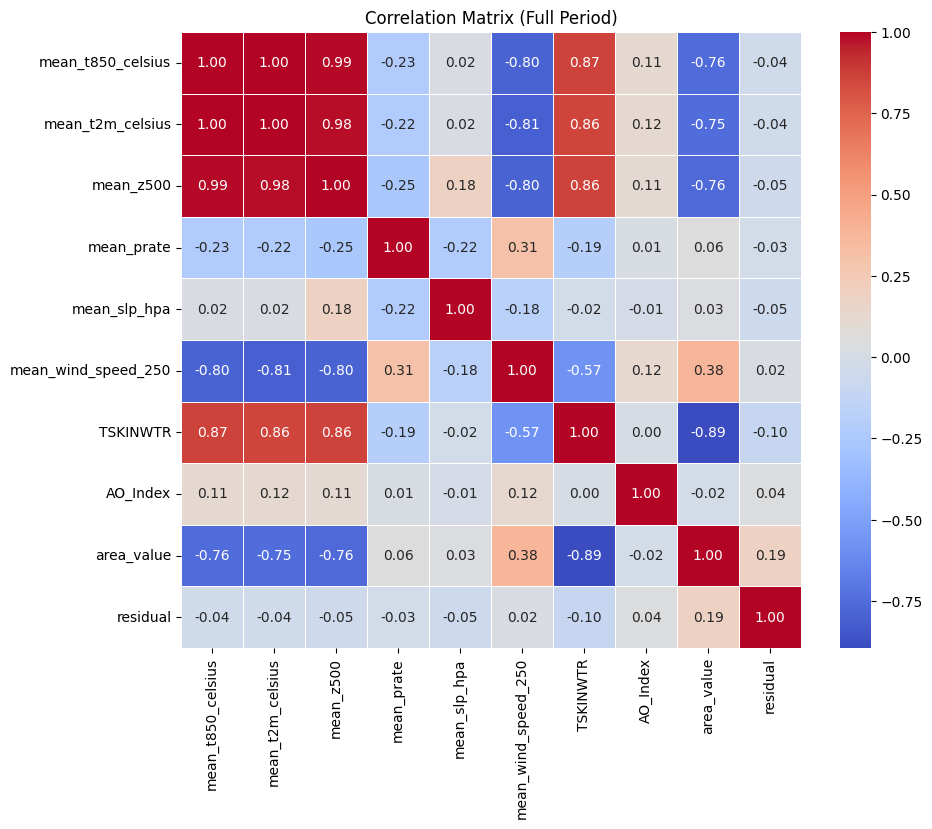

잔차(이상 정도)와 다른 변수들의 상관관계 (전체 기간 기준):


,residual
residual,1.000000
area_value,0.186667
AO_Index,0.044105
mean_wind_speed_250,0.018816
mean_prate,-0.028413
mean_t850_celsius,-0.037485
mean_t2m_celsius,-0.038100
mean_z500,-0.048841
mean_slp_hpa,-0.051895
TSKINWTR,-0.102011


In [ ]:
# ==================== Cell 7: [수정] 상관관계 분석 - 전체 기간 기준으로 변경 ====================

numeric_cols = df_combined.select_dtypes(include=np.number).columns
exclude_cols = ['anomaly_stat', 'anomaly_iso', 'resid_rolling_mean', 'resid_rolling_std',
                 'z_score', 'anomaly_score_iso', 'year', 'month', 'trend', 'seasonal']
correlation_df = df_combined[numeric_cols].drop(columns=exclude_cols, errors='ignore')
correlation_matrix = correlation_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix (Full Period)')
plt.show()

residual_correlations = correlation_matrix['residual'].sort_values(ascending=False)
print("잔차(이상 정도)와 다른 변수들의 상관관계 (전체 기간 기준):")
display(residual_correlations)

In [ ]:
# ==================== Cell 8: [분리] area_value 자체 예측 모델 (탐색적 분석 용도) ====================
# 주의: 이 모델은 '이상치 탐지'가 아니라 area_value 자체를 예측하는 별도 회귀 모델입니다.
# 여기서 나온 잔차를 다시 "해빙 이상치"로 쓰면, AO/SST 정보가 이상치 안에 이미 섞여 들어가
# 2단계(유럽기후 예측) 모델이 AO/SST를 다시 입력할 때 순환 구조가 생깁니다.
# -> 2단계로 넘길 핵심 산출물은 Cell 4~5의 area_value 자체 기반 결과를 사용하고,
#    아래는 참고용 탐색적 분석으로 분리해서 관리하는 것을 권장합니다.
from lightgbm import LGBMRegressor

lags_to_create = {
    'area_value': [1, 3, 6, 12],
    'mean_t850_celsius': [1, 3, 6, 12],
    'TSKINWTR': [1, 3, 6, 12],
    'AO_Index': [1, 3, 6, 12],
}
df_lagged = df_combined.copy()
for col, lags in lags_to_create.items():
    for lag in lags:
        df_lagged[f'{col}_lag_{lag}'] = df_lagged[col].shift(lag)
df_lagged.dropna(inplace=True)

In [ ]:
# [수정] 기존엔 area_value_lag_12만 선택적으로 제외(의도 불명확한 인컨시스턴시).
# 목적을 명시적으로 정하기: 여기서는 "순수 기후변수만으로 예측" 버전을 기본값으로 둠.
# 자기회귀 성분(area_value의 과거값)까지 쓰고 싶다면 area_value_lag_* 를 제외 목록에서 빼면 됨.
exclude_target_leak = ['area_value'] + [c for c in df_lagged.columns if c.startswith('area_value_lag')]
X = df_lagged.drop(columns=exclude_target_leak, errors='ignore')
y = df_lagged['area_value']

split_point = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

print(f"훈련 세트: {len(X_train)}개 ({X_train.index.min()} ~ {X_train.index.max()})")
print(f"테스트 세트: {len(X_test)}개 ({X_test.index.min()} ~ {X_test.index.max()})")

훈련 세트: 244개 (2001-01-01 00:00:00 ~ 2021-04-01 00:00:00)
테스트 세트: 61개 (2021-05-01 00:00:00 ~ 2026-05-01 00:00:00)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000156 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2235
[LightGBM] [Info] Number of data points in the train set: 244, number of used features: 28
[LightGBM] [Info] Start training from score 10.925498
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

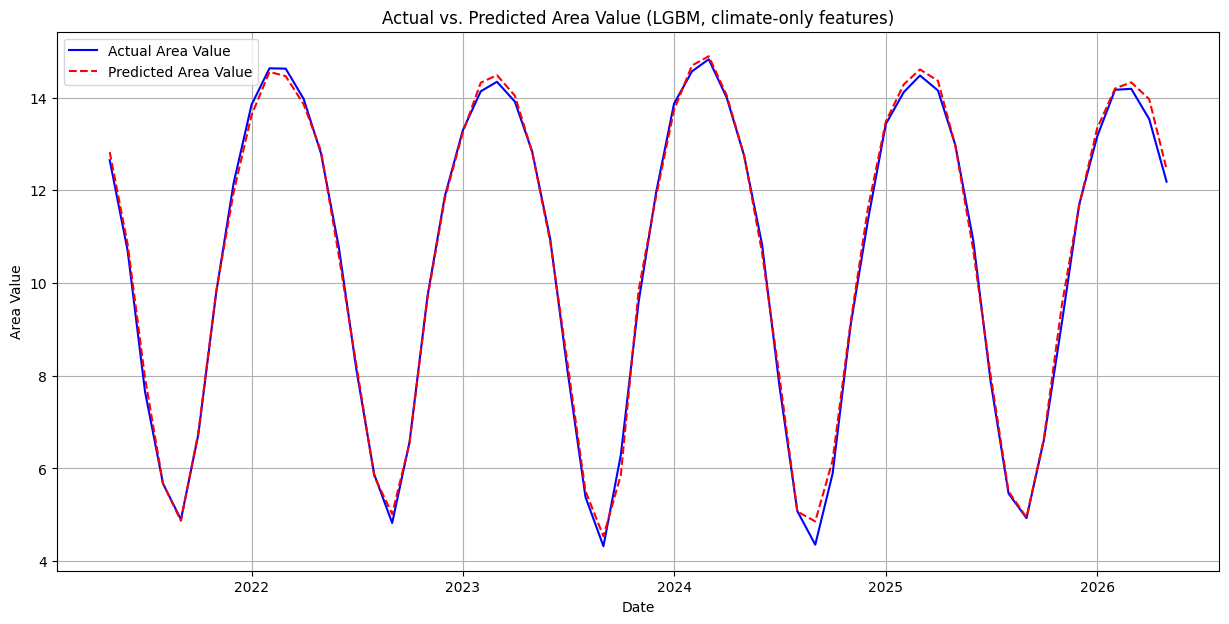

In [ ]:
# [수정] 기존 코드에 model 학습 부분이 빠져 있었음 (model.predict만 호출됨)
model = LGBMRegressor(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

plt.figure(figsize=(15, 7))
plt.plot(y_test.index, y_test, label='Actual Area Value', color='blue')
plt.plot(y_test.index, y_pred, label='Predicted Area Value', color='red', linestyle='--')
plt.title('Actual vs. Predicted Area Value (LGBM, climate-only features)')
plt.xlabel('Date'); plt.ylabel('Area Value'); plt.legend(); plt.grid(True)
plt.show()

In [ ]:
# ==================== Cell 9: [추가] 2단계(유럽기후 예측) 팀원에게 넘길 최종 출력 ====================
handoff = df_combined[['area_value', 'residual', 'z_score', 'anomaly_stat',
                        'anomaly_score_iso', 'anomaly_iso']].copy()
handoff['rolling_std_3'] = df_combined['area_value'].rolling(3, min_periods=1).std()
handoff['rolling_std_6'] = df_combined['area_value'].rolling(6, min_periods=1).std()
handoff['rolling_std_12'] = df_combined['area_value'].rolling(12, min_periods=1).std()

handoff.to_csv('/content/drive/MyDrive/arctic_data/sea_ice_anomaly_output.csv')
print("2단계 핸드오프 파일 저장 완료: sea_ice_anomaly_output.csv")
display(handoff.head())


2단계 핸드오프 파일 저장 완료: sea_ice_anomaly_output.csv


,area_value,residual,z_score,anomaly_stat,anomaly_score_iso,anomaly_iso,rolling_std_3,rolling_std_6,rolling_std_12
year_month,,,,,,,,,
2000-01-01,14.25950,0.044962,NaN,False,0.542047,False,NaN,NaN,NaN
2000-02-01,15.14771,-0.016477,-0.707107,False,0.446712,False,0.628059,0.628059,0.628059
2000-03-01,15.25001,-0.086149,-1.020263,False,0.425855,False,0.544746,0.544746,0.544746
2000-04-01,14.57881,-0.041159,-0.300945,False,0.435572,False,0.361622,0.470515,0.470515
2000-05-01,13.21552,-0.040558,-0.264895,False,0.419969,False,1.036679,0.820901,0.820901


# 2. 유럽 평균 기온 예측

In [ ]:
!pip install catboost optuna shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as plt_sns
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
import optuna
import shap
import warnings

# Optuna 및 기본 경고 숨김
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 1. 데이터 로드 및 전처리
df_europe = pd.read_csv('/content/drive/MyDrive/YB_data/Summer_Project/europe_climate.csv')
df_europe['date'] = pd.to_datetime(df_europe['date'])
df_europe['year'] = df_europe['date'].dt.year
df_europe['month'] = df_europe['date'].dt.month
monthly_europe = df_europe.groupby(['year', 'month'])[['mean_t2m_celsius', 'mean_z500', 'mean_slp_hpa']].mean().reset_index()

df_area = pd.read_csv('/content/drive/MyDrive/YB_data/Summer_Project/area_long.csv')[['year', 'month_num', 'area_value']].rename(columns={'month_num': 'month'})
df_ao = pd.read_csv('/content/drive/MyDrive/YB_data/Summer_Project/AO_index.csv')[['YEAR', 'MONTH', 'AO_Index']].rename(columns={'YEAR': 'year', 'MONTH': 'month'})

df_arctic = pd.read_csv('/content/drive/MyDrive/YB_data/Summer_Project/Arctic_SST_Analysis_Data.csv')
df_arctic['time'] = pd.to_datetime(df_arctic['time'])
df_arctic['year'] = df_arctic['time'].dt.year
df_arctic['month'] = df_arctic['time'].dt.month
df_arctic = df_arctic.drop(columns=['time'])
df_arctic = df_arctic.groupby(['year', 'month']).mean().reset_index()

# 2. 데이터 병합
df = monthly_europe.merge(df_area, on=['year', 'month'], how='inner')
df = df.merge(df_ao, on=['year', 'month'], how='inner')
df = df.merge(df_arctic, on=['year', 'month'], how='inner')
df = df.sort_values(['year', 'month']).reset_index(drop=True)

# 3. 피처 엔지니어링 & 데이터 누수(Leakage) 방지
# 실제 예측 시 사용할 수 있는 과거 정보만 활용하기 위해 Lag 변수 생성
features_to_lag = [
    'area_value', 'AO_Index', 'FRSEAICE', 'TSKINWTR',
    'T10M', 'HFLUXWTR', 'EFLUXWTR'
]

for col in features_to_lag:
    df[f'{col}_lag1'] = df[col].shift(1)
    df[f'{col}_lag3'] = df[col].shift(3)
    df[f'{col}_lag6'] = df[col].shift(6)
    df[f'{col}_roll3_mean'] = df[col].shift(1).rolling(window=3).mean()

# 해빙 변동성(3·6·12개월 표준편차) 생성
df['FRSEAICE_roll3_std'] = df['FRSEAICE'].shift(1).rolling(3).std()
df['FRSEAICE_roll6_std'] = df['FRSEAICE'].shift(1).rolling(6).std()
df['FRSEAICE_roll12_std'] = df['FRSEAICE'].shift(1).rolling(12).std()

df['area_value_roll3_std'] = df['area_value'].shift(1).rolling(3).std()
df['area_value_roll6_std'] = df['area_value'].shift(1).rolling(6).std()
df['area_value_roll12_std'] = df['area_value'].shift(1).rolling(12).std()

# 계절성을 표현하기 위한 월 주기 변수 생성
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

df = df.dropna().reset_index(drop=True)

TARGET = 'mean_t2m_celsius'

# 현재 월 정보는 미래 예측 시 사용할 수 없으므로 제외
drop_cols = ['month', TARGET, 'mean_z500', 'mean_slp_hpa'] + features_to_lag

train_df = df[df['year'] <= 2023].reset_index(drop=True)
test_df = df[(df['year'] >= 2024) & (df['year'] <= 2025)].reset_index(drop=True)

# 4. Ablation Study (TimeSeriesSplit)
print("4. Ablation Study (TimeSeriesSplit)")

# 해빙 변수 포함 여부에 따른 성능 비교를 위해 세 가지 피처셋 구성
all_features = [c for c in df.columns if c not in drop_cols]
sea_ice_cols = [c for c in all_features if 'area' in c or 'FRSEAICE' in c]
sea_ice_std_cols = [c for c in sea_ice_cols if 'std' in c]

features_m1 = [c for c in all_features if c not in sea_ice_cols]  # 해빙 변수 제외
features_m2 = [c for c in all_features if c not in sea_ice_std_cols] # 해빙 변수 포함
features_m3 = all_features     # 해빙 + 변동성 변수 포함

# 시계열 교차검증(TimeSeriesSplit) 설정
tscv = TimeSeriesSplit(n_splits=5)

def evaluate_tscv(features_list):
    cv_rmses = []
    X, y = train_df[features_list], train_df[TARGET]

    for train_idx, val_idx in tscv.split(X):
        X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

        model = lgb.LGBMRegressor(n_estimators=200, random_state=42, verbose=-1)
        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)
        cv_rmses.append(np.sqrt(mean_squared_error(y_val, preds)))

    return np.mean(cv_rmses)

rmse_m1 = evaluate_tscv(features_m1)
rmse_m2 = evaluate_tscv(features_m2)
rmse_m3 = evaluate_tscv(features_m3)

# Ablation Study 결과 출력
print(f"{'Model':<20} | {'RMSE':<8} | {'ΔRMSE':<8} | {'Improvement':<12}")
print("-" * 55)
print(f"{'No Sea Ice':<20} | {rmse_m1:.4f}   | {'-':<8} | {'-':<12}")

diff_2 = rmse_m2 - rmse_m1
imp_2 = (rmse_m1 - rmse_m2) / rmse_m1 * 100
print(f"{'+ Sea Ice':<20} | {rmse_m2:.4f}   | {diff_2:+.4f}  | {imp_2:+.2f}%")

diff_3 = rmse_m3 - rmse_m2
imp_3 = (rmse_m2 - rmse_m3) / rmse_m2 * 100
print(f"{'+ Sea Ice Std':<20} | {rmse_m3:.4f}   | {diff_3:+.4f}  | {imp_3:+.2f}%")
print("-" * 55)

# 성능이 가장 우수한 피처셋을 최종 모델에 사용
best_rmse = min(rmse_m1, rmse_m2, rmse_m3)
if best_rmse == rmse_m1:
    print("결론 : 해빙 변수를 제외한 모델(No Sea Ice)이 가장 우수하여 이를 최종 피처로 채택")
    if rmse_m3 < rmse_m2:
        print("      (해빙 면적 추가 시 성능이 하락했으나, 변동성을 함께 고려하면 하락폭이 다소 방어됨을 확인)")
    best_features = features_m1
elif best_rmse == rmse_m2:
    print("결론 : 해빙 면적 변수를 포함한 모델이 가장 우수하여 이를 최종 피처로 채택")
    best_features = features_m2
else:
    print("결론 : 해빙 면적과 변동성(Std) 변수를 모두 포함한 모델이 가장 우수하여 이를 최종 피처로 채택")
    best_features = features_m3

# 5. Optuna 기반 LightGBM 하이퍼파라미터 튜닝
print("\n5. Optuna Hyperparameter Tuning")

# 선택된 피처셋을 대상으로 최적의 하이퍼파라미터 탐색
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'num_leaves': trial.suggest_int('num_leaves', 15, 63),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': 42,
        'verbose': -1
    }

    cv_rmses = []
    X, y = train_df[best_features], train_df[TARGET]

    for train_idx, val_idx in tscv.split(X):
        X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

        model = lgb.LGBMRegressor(**params)
        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)
        cv_rmses.append(np.sqrt(mean_squared_error(y_val, preds)))

    return np.mean(cv_rmses)

# Optuna를 이용한 하이퍼파라미터 탐색
sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction='minimize', sampler=sampler)
study.optimize(objective, n_trials=500)
best_lgb_params = study.best_params
print(f" 최적 파라미터: {best_lgb_params}")

# 6. 모델 성능 비교 및 최종 모델 선정
print("\n6. 모델 비교 (2024~2025 검증)")

# 학습 데이터와 테스트 데이터 구성
X_train, y_train = train_df[best_features], train_df[TARGET]
X_test, y_test = test_df[best_features], test_df[TARGET]

# LightGBM, XGBoost, CatBoost 모델 생성
models = {
    'LightGBM (Tuned)': lgb.LGBMRegressor(**best_lgb_params, random_state=42, verbose=-1),
    'XGBoost': xgb.XGBRegressor(n_estimators=300, random_state=42, learning_rate=0.05, max_depth=5, objective='reg:squarederror'),
    'CatBoost': CatBoostRegressor(iterations=300, random_state=42, learning_rate=0.05, depth=5, verbose=0)
}

# 각 모델의 성능 평가
predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    predictions[name] = preds
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    print(f" {name:16s} Test RMSE: {rmse:.4f}")

# 앙상블 모델 성능 확인
# Ensemble은 최고 성능을 보였지만, 개별 변수 영향 해석(SHAP)의 일관성을 위해 단일 모델인 LightGBM을 최종 모델로 선정
preds_ens = (predictions['LightGBM (Tuned)'] + predictions['XGBoost'] + predictions['CatBoost']) / 3
ens_rmse = np.sqrt(mean_squared_error(y_test, preds_ens))
print(f" {'Ensemble':16s} Test RMSE: {ens_rmse:.4f}")

print("\n단일 LightGBM 모델을 최종 모델로 선정")
final_model = models['LightGBM (Tuned)']

# 7. 2026년 하반기 기온 예측
print("\n7. [최종 예측 결과] 2026년 7월~12월 유럽 평균 기온")

# 전체 데이터를 이용하여 최종 모델 재학습
final_model.fit(df[best_features], df[TARGET])

# 최근 5년(2021~2025) 평균 패턴을 이용해 입력 데이터 생성
recent_years_df = df[df['year'] >= 2021]
recent_monthly_avg = recent_years_df.groupby('month')[best_features].mean()

# 2026년 7~12월 기온 예측
for m in range(7, 13):
    pred_row = recent_monthly_avg.loc[m].copy()
    if 'year' in best_features:
        pred_row['year'] = 2026
    pred_row['month_sin'] = np.sin(2 * np.pi * m / 12)
    pred_row['month_cos'] = np.cos(2 * np.pi * m / 12)

    pred_df = pd.DataFrame([pred_row], columns=best_features)
    pred_val = final_model.predict(pred_df)[0]

    print(f" 2026년 {m:02d}월 예측 기온: {pred_val:6.3f} °C")

4. Ablation Study (TimeSeriesSplit)
Model                | RMSE     | ΔRMSE    | Improvement 
-------------------------------------------------------
No Sea Ice           | 0.9194   | -        | -           
+ Sea Ice            | 0.9425   | +0.0230  | -2.51%
+ Sea Ice Std        | 0.9248   | -0.0176  | +1.87%
-------------------------------------------------------
결론 : 해빙 변수를 제외한 모델(No Sea Ice)이 가장 우수하여 이를 최종 피처로 채택
      (해빙 면적 추가 시 성능이 하락했으나, 변동성을 함께 고려하면 하락폭이 다소 방어됨을 확인)

5. Optuna Hyperparameter Tuning
 최적 파라미터: {'n_estimators': 118, 'learning_rate': 0.08322122832198935, 'max_depth': 4, 'num_leaves': 39, 'subsample': 0.8453038902445653, 'colsample_bytree': 0.6241341816332271}

6. 모델 비교 (2024~2025 검증)
 LightGBM (Tuned) Test RMSE: 0.6091
 XGBoost          Test RMSE: 0.6509
 CatBoost         Test RMSE: 0.6795
 Ensemble         Test RMSE: 0.6106

단일 LightGBM 모델을 최종 모델로 선정

7. [최종 예측 결과] 2026년 7월~12월 유럽 평균 기온
 2026년 07월 예측 기온: 17.819 °C
 2026년 08월 예측 기온: 17.566 °C
 2026년 09월 예측 기온: 14.

# 3. 유럽 기온 이상치 예측

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error

In [ ]:
temp1 = pd.read_csv("europe_daily_summary_2000_202603.csv", parse_dates=["date"])
temp2 = pd.read_csv("europe_daily_summary_202603_202606_era5.csv", parse_dates=["date"])
temp_daily = pd.concat([temp1[["date", "mean_t2m_celsius"]], temp2[["date", "mean_t2m_celsius"]]])
temp_daily = temp_daily.drop_duplicates(subset="date").sort_values("date")
temp_daily["year"] = temp_daily["date"].dt.year
temp_daily["month"] = temp_daily["date"].dt.month

monthly_temp = temp_daily.groupby(["year", "month"])["mean_t2m_celsius"].mean().reset_index()
monthly_temp = monthly_temp.rename(columns={"mean_t2m_celsius": "temp_mean"})

ao = pd.read_csv("ao_filtered.csv").rename(columns={"YEAR": "year", "MONTH": "month"})
ao = ao[["year", "month", "AO_Index"]]

sst = pd.read_csv("Arctic_SST_Analysis_Data.csv", parse_dates=["time"])
sst["year"] = sst["time"].dt.year
sst["month"] = sst["time"].dt.month
sst["TSKINWTR_C"] = sst["TSKINWTR"] - 273.15

area = pd.read_csv("area_long.csv")
area = area[["year", "month_num", "area_value"]].rename(columns={"month_num": "month"})

In [ ]:
area_pieces = []
for m in range(1, 13):
    one_month = area[area["month"] == m].sort_values("year").copy()
    one_month["area_std_by_month"] = one_month["area_value"].expanding(min_periods=3).std()
    area_pieces.append(one_month)
area = pd.concat(area_pieces).sort_values(["year", "month"]).reset_index(drop=True)

In [ ]:
df = monthly_temp.merge(ao, on=["year", "month"], how="left")
df = df.merge(sst[["year", "month", "TSKINWTR_C", "FRSEAICE"]], on=["year", "month"], how="left")
df = df.merge(area[["year", "month", "area_value", "area_std_by_month"]], on=["year", "month"], how="left")
df = df.sort_values(["year", "month"]).reset_index(drop=True)

df["t"] = (df["year"] - df["year"].min()) * 12 + (df["month"] - 1)

In [ ]:
df = monthly_temp.merge(ao, on=["year", "month"], how="left")
df = df.merge(sst[["year", "month", "TSKINWTR_C", "FRSEAICE"]], on=["year", "month"], how="left")
df = df.merge(area[["year", "month", "area_value", "area_std_by_month"]], on=["year", "month"], how="left")
df = df.sort_values(["year", "month"]).reset_index(drop=True)

df["t"] = (df["year"] - df["year"].min()) * 12 + (df["month"] - 1)

In [ ]:
ALL_FEATURES = ["AO_Index", "TSKINWTR_C", "FRSEAICE", "area_value", "area_std_by_month"]
df_idx = df.set_index("t")

rows = []
for t in df_idx.index:
    target = df_idx.loc[t, "temp_anomaly"]
    if pd.isna(target):
        continue
    for h in range(1, 10):
        t_src = t - h
        if t_src not in df_idx.index:
            continue
        src = df_idx.loc[t_src]
        if src[ALL_FEATURES].isna().any():
            continue
        row = {"year": df_idx.loc[t, "year"], "month": df_idx.loc[t, "month"], "h": h, "target": target}
        for f in ALL_FEATURES:
            row[f + "_lag"] = src[f]
        rows.append(row)

panel = pd.DataFrame(rows)
panel["month_sin"] = np.sin(2 * np.pi * panel["month"] / 12)
panel["month_cos"] = np.cos(2 * np.pi * panel["month"] / 12)
panel["year_trend"] = panel["year"] - 2000

COMMON_COLS = ["h", "month_sin", "month_cos", "year_trend"]

In [ ]:
feature_sets = {
    "A. AO+해수면 (해빙면적 제외)": ["AO_Index_lag", "TSKINWTR_C_lag", "FRSEAICE_lag"] + COMMON_COLS,
    "B. AO+해수면+해빙면적": ["AO_Index_lag", "TSKINWTR_C_lag", "FRSEAICE_lag", "area_value_lag"] + COMMON_COLS,
    "C. AO+해수면+해빙면적+표준편차": ["AO_Index_lag", "TSKINWTR_C_lag", "FRSEAICE_lag", "area_value_lag", "area_std_by_month_lag"] + COMMON_COLS,
    "D. 해수면+해빙면적+표준편차 (AO 제외)": ["TSKINWTR_C_lag", "FRSEAICE_lag", "area_value_lag", "area_std_by_month_lag"] + COMMON_COLS,
}

In [ ]:
train = panel[panel["year"] < 2024]
test = panel[panel["year"] >= 2024]

In [ ]:
results = []
fitted_models = {}
for name, cols in feature_sets.items():
    X_train, y_train = train[cols], train["target"]
    X_test, y_test = test[cols], test["target"]

    model = HistGradientBoostingRegressor(
        max_depth=2, learning_rate=0.03, max_iter=150, l2_regularization=1.0, random_state=42
    )
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))

    results.append({"조합": name, "RMSE": round(rmse, 4)})
    fitted_models[name] = (model, cols)

result_df = pd.DataFrame(results)
print("===== 조합별 성능 비교 (HistGradientBoosting) =====")
print(result_df.to_string(index=False))

===== 조합별 성능 비교 (HistGradientBoosting) =====
                      조합   RMSE
     A. AO+해수면 (해빙면적 제외) 0.7272
          B. AO+해수면+해빙면적 0.7268
     C. AO+해수면+해빙면적+표준편차 0.7239
D. 해수면+해빙면적+표준편차 (AO 제외) 0.7252


In [ ]:
best_name = result_df.sort_values("RMSE").iloc[0]["조합"]
best_model, best_cols = fitted_models[best_name]
print(f"\n가장 성능이 좋은 조합: {best_name}")

last_t = df_idx[ALL_FEATURES].dropna().index.max()
last_row = df_idx.loc[last_t]

forecast_list = []
for month in [7, 8, 9, 10, 11, 12]:
    target_t = (2026 - df["year"].min()) * 12 + (month - 1)
    h = target_t - last_t
    new_row = {f + "_lag": last_row[f] for f in ALL_FEATURES}
    new_row["h"] = h
    new_row["month_sin"] = np.sin(2 * np.pi * month / 12)
    new_row["month_cos"] = np.cos(2 * np.pi * month / 12)
    new_row["year_trend"] = 2026 - 2000
    X_new = pd.DataFrame([new_row])[best_cols]
    pred_anomaly = best_model.predict(X_new)[0]
    forecast_temp = climatology.loc[month] + pred_anomaly
    forecast_list.append({"month": month, "예측_이상치": round(pred_anomaly, 3), "예측_기온": round(forecast_temp, 2)})

forecast_df = pd.DataFrame(forecast_list)
print("\n===== 2026년 7~12월 예측 (최고 성능 조합 기준) =====")
print(forecast_df)


가장 성능이 좋은 조합: C. AO+해수면+해빙면적+표준편차

===== 2026년 7~12월 예측 (최고 성능 조합 기준) =====
   month  예측_이상치  예측_기온
0      7   0.181  17.37
1      8   0.181  17.42
2      9   0.276  14.54
3     10   0.319  10.38
4     11   0.319   6.29
5     12   0.342   3.47
